# Confidence Interval using Z-Procedure

In [145]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Example 1: Population is Approximately Normal

In [2]:
iris = sns.load_dataset("iris")

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
population = iris["sepal_length"]

In [7]:
population.shape

(150,)

# 

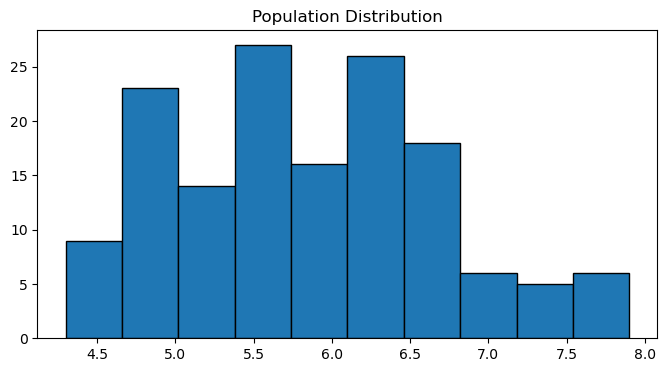

In [17]:
plt.figure(figsize=(8,4))
plt.hist(population, bins=10, edgecolor="black")
plt.title("Population Distribution")
plt.show()

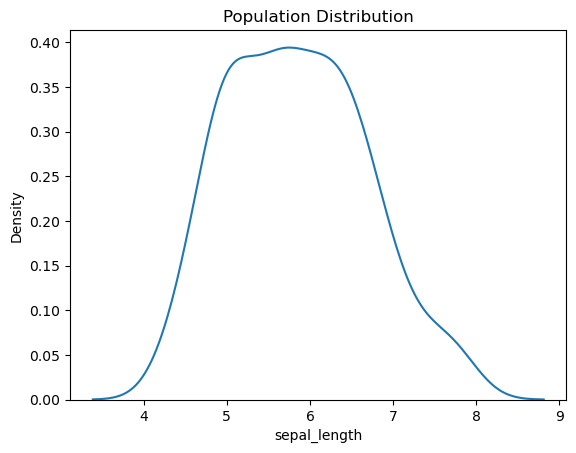

In [19]:
sns.kdeplot(population)
plt.title("Population Distribution")
plt.show()

# 

In [90]:
population_mean = population.mean()
population_std = population.std(ddof=0)

In [91]:
print('Population Mean :', population_mean)
print('Population Std  :', population_std)

Population Mean : 32.204207968574636
Population Std  : 49.66553444477411


# 

In [29]:
sample = population.sample(n=30, random_state=42)

In [30]:
sample_mean = sample.mean()

#### Z Procedure

In [36]:
z = norm.ppf(0.975)

In [42]:
z

np.float64(1.959963984540054)

In [44]:
SE = population_std / np.sqrt(30)

In [47]:
SE

np.float64(0.15067871141629158)

In [48]:
Margin_Error = z * SE

In [49]:
Margin_Error

np.float64(0.2953248476128358)

In [51]:
lower = sample_mean - Margin_Error
upper = sample_mean + Margin_Error

# 

In [54]:
print("\n95% Confidence Interval")
print(f"{lower:.3f} - {upper:.3f}")


95% Confidence Interval
5.685 - 6.275


In [55]:
print("\nPopulation Mean :", population_mean)


Population Mean : 5.843333333333334


# 

# 

## 2. Population is NOT Normal,

In [58]:
titanic = sns.load_dataset("titanic")

In [59]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [60]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [64]:
population2 = titanic["fare"]

In [69]:
population2.shape

(891,)

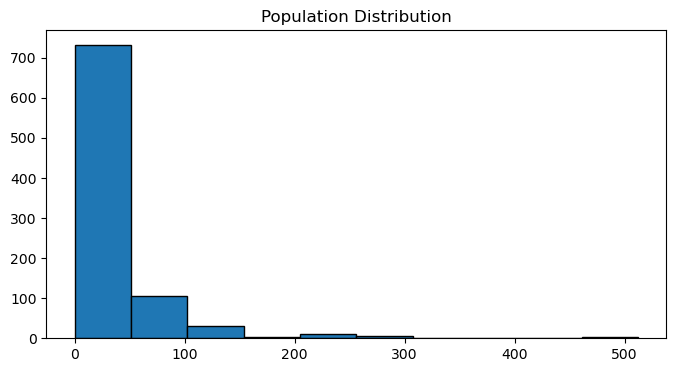

In [92]:
plt.figure(figsize=(8,4))
plt.hist(population2, bins=10, edgecolor="black")
plt.title("Population Distribution")
plt.show()

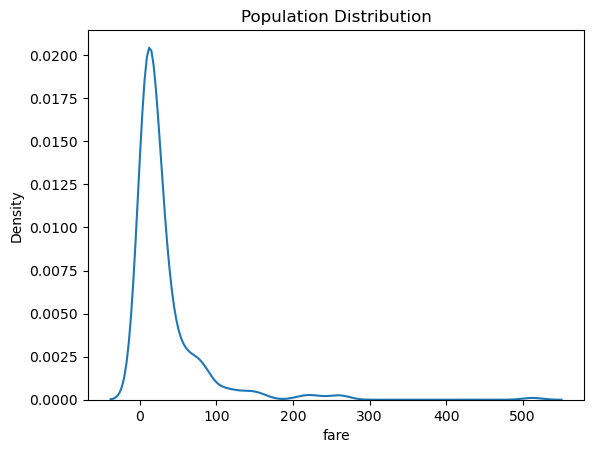

In [93]:
sns.kdeplot(population)
plt.title("Population Distribution")
plt.show()

In [95]:
population_mean2 = population2.mean()
population_std2 = population2.std(ddof=0)

In [97]:
print('Population Mean :', population_mean2)
print('Population Std  :', population_std2)

Population Mean : 32.204207968574636
Population Std  : 49.66553444477411


In [98]:
# One Random Sample (n >= 30)
sample2 = population2.sample(n=30, random_state=42)

In [99]:
sample2.head()

709    15.2458
439    10.5000
840     7.9250
720    33.0000
39     11.2417
Name: fare, dtype: float64

In [100]:
sample_mean2 = sample2.mean()

In [101]:
sample_mean2

np.float64(21.95236333333333)

In [102]:
population_mean2

np.float64(32.204207968574636)

# 

#### Z Procedure

In [109]:
z2 = norm.ppf(0.975)

In [110]:
z2

np.float64(1.959963984540054)

In [112]:
SE2 = population_std2 / np.sqrt(30)

In [113]:
SE2

np.float64(9.067644515317532)

In [115]:
Margin_Error2 = z2 * SE2

In [116]:
Margin_Error2

np.float64(17.77225667463452)

lower2 = sample_mean2 - ME2
upper2 = sample_mean2 + ME2

In [117]:
lower2 = sample_mean2 - Margin_Error2
upper2 = sample_mean2 + Margin_Error2

In [142]:
print("\n95% Confidence Interval")
print(f"({lower2:.3f} - {upper2:.3f})")


95% Confidence Interval
(4.180 - 39.725)


# 

### sampling Destribution

In [146]:
sample_size = 30
sample_means3 = []

In [147]:
for i in range(100):
    sample = population2.sample(n=sample_size)
    sample_means3.append(sample.mean())

In [148]:
sample_means3 = np.array(sample_means)

In [149]:
sample_means3.shape

(200,)

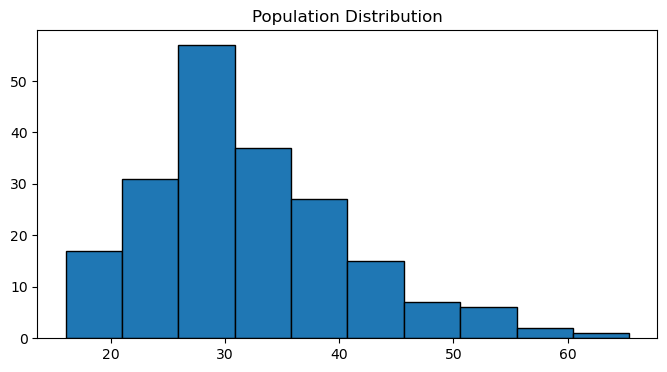

In [150]:
plt.figure(figsize=(8,4))
plt.hist(sample_means3, bins=10, edgecolor="black")
plt.title("Population Distribution")
plt.show()

In [151]:
sample_means3 = sample_means3.mean()

In [152]:
sample_means3

np.float64(31.954639399999998)

In [153]:
lower3 = sample_means3 - Margin_Error2
upper3 = sample_means3 + Margin_Error2

In [154]:
print("\n95% Confidence Interval")
print(f"({lower3:.3f} - {upper3:.3f})")


95% Confidence Interval
(14.182 - 49.727)


In [155]:
population_mean2

np.float64(32.204207968574636)

In [156]:
sample_means3

np.float64(31.954639399999998)